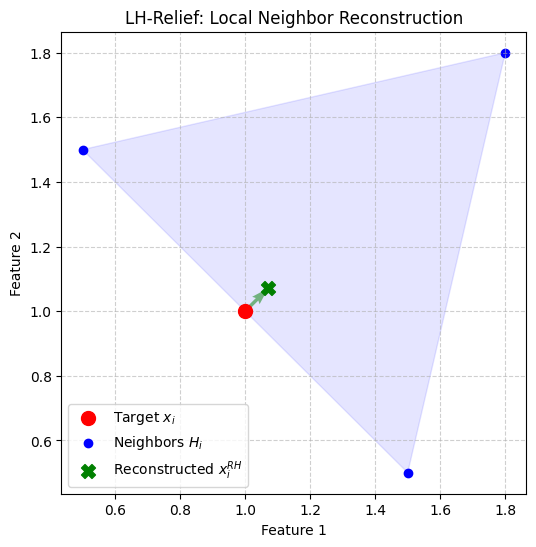

目標點: [1. 1.]
重構出的虛擬鄰居點: [1.07110315 1.07110315]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def project_to_simplex(v):
    """將向量投影到機率單體 (sum=1, v>=0)"""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / np.arange(1, n + 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)

def lh_reconstruction(target_x, neighbors, weights, lam_r=0.001, iters=100):
    """
    實作局部鄰居重構
    target_x: (m,) 目標點
    neighbors: (k, m) 鄰居矩陣
    weights: (m,) 特徵權重
    """
    k = neighbors.shape[0]
    W = np.diag(weights)

    # 預計算 H_bar 與 c (公式 177)
    WH_t = (W @ neighbors.T)
    H_bar = 2 * lam_r * np.eye(k) + WH_t.T @ WH_t
    Wx = target_x @ W
    c = -Wx @ WH_t

    # 投影梯度下降求解 alpha
    alpha = np.ones(k) / k  # 初始化
    lr = 0.1 / np.max(np.abs(H_bar)) # 學習率

    for _ in range(iters):
        grad = H_bar @ alpha + c.flatten()
        alpha = alpha - lr * grad
        alpha = project_to_simplex(alpha) # 限制條件 sum=1, alpha>=0

    return neighbors.T @ alpha

# --- 2D 數據視覺化測試 ---
np.random.seed(42)
target = np.array([1.0, 1.0])
# 產生三個鄰居點
neighbors = np.array([[1.5, 0.5], [0.5, 1.5], [1.8, 1.8]])
weights = np.array([1.0, 1.0]) # 假設權重均等

# 執行重構
reconstructed = lh_reconstruction(target, neighbors, weights)

# 繪圖
plt.figure(figsize=(6, 6))
plt.scatter(target[0], target[1], color='red', s=100, label='Target $x_i$', zorder=5)
plt.scatter(neighbors[:, 0], neighbors[:, 1], color='blue', label='Neighbors $H_i$')
# 畫出鄰居構成的三角形範圍
poly = plt.Polygon(neighbors, color='blue', alpha=0.1)
plt.gca().add_patch(poly)
plt.scatter(reconstructed[0], reconstructed[1], color='green', s=100, marker='X', label='Reconstructed $x_i^{RH}$')

plt.quiver(target[0], target[1], reconstructed[0]-target[0], reconstructed[1]-target[1],
           angles='xy', scale_units='xy', scale=1, color='green', alpha=0.5)

plt.title("LH-Relief: Local Neighbor Reconstruction")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"目標點: {target}")
print(f"重構出的虛擬鄰居點: {reconstructed}")

In [ ]:
import numpy as np

# 目標點：訊號在 5，雜訊在 10
target = np.array([5.0, 10.0])

# 鄰居群：訊號都很接近 5，但雜訊 y 軸亂跳
neighbors = np.array([
    [5.1, 0.0],  # y 很遠
    [4.9, 20.0], # y 很遠
    [5.0, 5.0]   # y 較近
])

# 1. 如果不加 W (即 W = [1, 1]):
# 重構會試圖去匹配 y=10 這個雜訊，導致 alpha 偏向 y 較近的鄰居。

# 2. 如果加入 W = [1.0, 0.01] (壓縮雜訊維度):
# 重構會發現 y 軸的誤差不重要，因此會精確地在 x=5 附近找到平衡，
# 即使 y 軸對不準也沒關係。